<a href="https://colab.research.google.com/github/snehapradeep25/-Internship-Project---NPOL-/blob/main/CRNN_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
loading dataset and libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model('/content/drive/MyDrive/ship_models/crnn_checkpoints/crnn_best.keras')
model.export('/content/crnn_savedmodel')
!zip -r crnn_savedmodel.zip crnn_savedmodel/
from google.colab import files
files.download('crnn_savedmodel.zip')

In [ ]:
import zipfile
import os
zipfile.ZipFile('/content/drive/MyDrive/Project/vtuad_dataset.zip').extractall('/content/vtuad/')

In [ ]:
# Install required libraries
!pip install librosa tensorflow matplotlib seaborn scikit-learn

import numpy as np
import librosa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from pathlib import Path
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

file path

In [ ]:

DATASET_ROOT = '/content/vtuad/inclusion_2000_exclusion_4000/'
TRAIN_PATH = os.path.join(DATASET_ROOT, 'train')
VAL_PATH = os.path.join(DATASET_ROOT, 'validation')
TEST_PATH = os.path.join(DATASET_ROOT, 'test')

MODEL_SAVE_PATH = '/content/drive/MyDrive/ship_models/'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

In [ ]:

def get_file_lists(split_path):
    """Get audio file paths and labels"""
    files = []
    labels = []

    for class_idx, class_name in enumerate(['background', 'cargo', 'passengership', 'tanker', 'tug']):
        class_dir = os.path.join(split_path, 'audio', class_name)

        if os.path.exists(class_dir):
            for audio_file in os.listdir(class_dir):
                if audio_file.endswith('.wav'):
                    files.append(os.path.join(class_dir, audio_file))
                    labels.append(class_idx)

    return np.array(files), np.array(labels)

print("Loading file lists...")
train_files, train_labels = get_file_lists(TRAIN_PATH)
val_files, val_labels = get_file_lists(VAL_PATH)
test_files, test_labels = get_file_lists(TEST_PATH)

print(f"✅ Train: {len(train_files)} files")
print(f"✅ Val: {len(val_files)} files")
print(f"✅ Test: {len(test_files)} files")

print("\nClass distribution (Train):")
for i, name in enumerate(['background', 'cargo', 'passengership', 'tanker', 'tug']):
    count = (train_labels == i).sum()
    print(f"  {name}: {count}")

extracting mel spectrogram

In [ ]:
import numpy as np
import librosa
from tqdm import tqdm

def extract_mel_spectrogram(file_path, sr=32000, n_mels=128,
                            n_fft=2048, hop_length=512, duration=1.0):
    """Extract mel spectrogram with ref=1.0 (CORRECT)"""
    try:
        audio, _ = librosa.load(file_path, sr=sr, duration=duration)

        target_length = int(sr * duration)
        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
        else:
            audio = audio[:target_length]

        mel_spec = librosa.feature.melspectrogram(
            y=audio, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
        )

        # CORRECT: ref=1.0 (NOT np.max!)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=1.0)

        return mel_spec_db

    except Exception as e:
        return None

In [ ]:
CONFIG = {
    'sample_rate': 32000,
    'duration': 1.0,
    'n_mels': 128,
    'n_fft': 2048,
    'hop_length': 512,
    'batch_size': 64,
    'epochs': 25,

}

NUM_CLASSES = 5

global normalisation

In [ ]:
print("Computing normalization stats from 1000 training samples...")

sample_size = 1000
sample_indices = np.random.choice(len(train_files), size=sample_size, replace=False)

all_mels = []
for idx in tqdm(sample_indices, desc="Extracting features"):
    mel = extract_mel_spectrogram(
        train_files[idx],
        sr=CONFIG['sample_rate'],
        n_mels=CONFIG['n_mels'],
        n_fft=CONFIG['n_fft'],
        hop_length=CONFIG['hop_length'],
        duration=CONFIG['duration']
    )
    if mel is not None:
        all_mels.append(mel)

# Compute stats
all_mels = np.array(all_mels)
GLOBAL_MEAN = all_mels.mean(axis=(0, 2), keepdims=True)
GLOBAL_STD = all_mels.std(axis=(0, 2), keepdims=True)

print(f"\n✅ Computed from {len(all_mels)} samples")
print(f"   Mean shape: {GLOBAL_MEAN.shape}")
print(f"   Mean range: [{GLOBAL_MEAN.min():.2f}, {GLOBAL_MEAN.max():.2f}]")
print(f"   Std shape: {GLOBAL_STD.shape}")
print(f"   Std range: [{GLOBAL_STD.min():.2f}, {GLOBAL_STD.max():.2f}]")

# Save
np.save('/content/drive/MyDrive/ship_models/global_mean.npy', GLOBAL_MEAN)
np.save('/content/drive/MyDrive/ship_models/global_std.npy', GLOBAL_STD)
print("\n Saved to Drive: global_mean.npy, global_std.npy")

Computing normalization stats from 1000 training samples...
(Takes ~2-3 minutes)



Extracting features: 100%|██████████| 1000/1000 [00:39<00:00, 25.22it/s] 



✅ Computed from 1000 samples
   Mean shape: (1, 128, 1)
   Mean range: [-70.61, 6.50]
   Std shape: (1, 128, 1)
   Std range: [3.56, 14.20]

✅ Saved to Drive: global_mean.npy, global_std.npy


crnn model architecture

In [ ]:
from tensorflow.keras import layers, models

def build_crnn_model(input_shape=(128, 63, 1), num_classes=5):
    """CRNN: CNN layers + RNN layers"""

    inputs = layers.Input(shape=input_shape)

    # CNN Block 1
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # CNN Block 2
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # CNN Block 3
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Reshape for RNN: (batch, freq, time, channels) → (batch, time, freq*channels)
    shape = x.shape
    x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

    # RNN Blocks
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.Dropout(0.3)(x)

    # Dense Head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs, name='CRNN_Model')

# Build
crnn_model = build_crnn_model(input_shape=(128, 63, 1), num_classes=NUM_CLASSES)

# Compile
crnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate = 0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("="*70)
print("CRNN MODEL (NO AUGMENTATION)")
print("="*70)
crnn_model.summary()

print(f"\nTotal parameters: {crnn_model.count_params():,}")

CRNN MODEL (NO AUGMENTATION)


Model: "CRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 63, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 63, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 63, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128, 63, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 7, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16, 7, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 2048)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 7, 256)         │     2,229,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,504,325 (9.55 MB)

 Trainable params: 2,503,877 (9.55 MB)

 Non-trainable params: 448 (1.75 KB)


📊 Total parameters: 2,504,325


data generator and training setup

In [ ]:
from tensorflow.keras import callbacks
import os


GLOBAL_MEAN = np.load('/content/drive/MyDrive/ship_models/global_mean.npy').reshape(128, 1)
GLOBAL_STD = np.load('/content/drive/MyDrive/ship_models/global_std.npy').reshape(128, 1)

print(f" Loaded normalization: mean={GLOBAL_MEAN.shape}, std={GLOBAL_STD.shape}")

def data_generator_crnn(file_paths, labels, batch_size, mean, std, shuffle=True):
    """Generate batches (identical to CNN/RNN)"""
    num_samples = len(file_paths)

    while True:
        indices = np.arange(num_samples)
        if shuffle:
            np.random.shuffle(indices)

        for start_idx in range(0, num_samples, batch_size):
            end_idx = min(start_idx + batch_size, num_samples)
            batch_indices = indices[start_idx:end_idx]

            batch_files = file_paths[batch_indices]
            batch_labels = labels[batch_indices]

            batch_features = []
            batch_targets = []

            for file_path, label in zip(batch_files, batch_labels):
                mel_spec = extract_mel_spectrogram(
                    file_path, sr=CONFIG['sample_rate'], n_mels=CONFIG['n_mels'],
                    n_fft=CONFIG['n_fft'], hop_length=CONFIG['hop_length'],
                    duration=CONFIG['duration']
                )

                if mel_spec is not None:
                    mel_norm = (mel_spec - mean) / std
                    batch_features.append(mel_norm)
                    batch_targets.append(label)

            if len(batch_features) > 0:
                X = np.array(batch_features)
                X = np.expand_dims(X, axis=-1)
                y = keras.utils.to_categorical(batch_targets, num_classes=NUM_CLASSES)
                yield X, y

# Create generators
steps_per_epoch_train = len(train_files) // CONFIG['batch_size']
steps_per_epoch_val = len(val_files) // CONFIG['batch_size']

train_gen = data_generator_crnn(train_files, train_labels, CONFIG['batch_size'],
                                 GLOBAL_MEAN, GLOBAL_STD, shuffle=True)
val_gen = data_generator_crnn(val_files, val_labels, CONFIG['batch_size'],
                               GLOBAL_MEAN, GLOBAL_STD, shuffle=False)

print(f" Steps/epoch: train={steps_per_epoch_train}, val={steps_per_epoch_val}")



CRNN_CHECKPOINT_DIR = '/content/drive/MyDrive/ship_models/crnn_checkpoints/'
os.makedirs(CRNN_CHECKPOINT_DIR, exist_ok=True)

checkpoint_best = callbacks.ModelCheckpoint(
    filepath=os.path.join(CRNN_CHECKPOINT_DIR, 'crnn_best.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

checkpoint_every = callbacks.ModelCheckpoint(
    filepath=os.path.join(CRNN_CHECKPOINT_DIR, 'crnn_epoch_{epoch:02d}.keras'),
    save_freq='epoch',
    verbose=0
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=CONFIG['patience'],
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("="*70)
print("STARTING CRNN TRAINING (NO AUGMENTATION)")
print("="*70)

# Train
history_crnn = crnn_model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch_train,
    epochs=CONFIG['epochs'],
    validation_data=val_gen,
    validation_steps=steps_per_epoch_val,
    callbacks=[checkpoint_best, checkpoint_every, early_stop, reduce_lr],
    verbose=1
)

print("\n CRNN TRAINING COMPLETE")
crnn_model.save(os.path.join(CRNN_CHECKPOINT_DIR, 'crnn_final.keras'))
print(f" Saved: crnn_final.keras")

loading model and continuing training

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


print("="*70)
print("LOADING BEST CRNN MODEL FOR EVALUATION")
print("="*70)

CRNN_MODEL_PATH = '/content/drive/MyDrive/ship_models/crnn_checkpoints/crnn_best.keras'
crnn_model = keras.models.load_model(CRNN_MODEL_PATH)

print(f" Loaded: {CRNN_MODEL_PATH}")
print(f"   Input shape: {crnn_model.input_shape}")
print(f"   Output shape: {crnn_model.output_shape}")

LOADING BEST CRNN MODEL FOR EVALUATION
 Loaded: /content/drive/MyDrive/ship_models/crnn_checkpoints/crnn_best.keras
   Input shape: (None, 128, 63, 1)
   Output shape: (None, 5)


test data preparation

In [ ]:
# Reload normalization stats
GLOBAL_MEAN = np.load('/content/drive/MyDrive/ship_models/global_mean.npy').reshape(128, 1)
GLOBAL_STD = np.load('/content/drive/MyDrive/ship_models/global_std.npy').reshape(128, 1)


test_gen = data_generator_crnn(test_files, test_labels, CONFIG['batch_size'],
                                GLOBAL_MEAN, GLOBAL_STD, shuffle=False)

steps_test = len(test_files) // CONFIG['batch_size']

print(f"\n Test set: {len(test_files)} samples, {steps_test} steps")


 Test set: 1880 samples, 29 steps


evaluation


🔮 Generating predictions on test set...
 Collected 1880 predictions

OVERALL TEST PERFORMANCE

🎯 Test Accuracy: 95.96%

PER-CLASS METRICS

               precision    recall  f1-score   support

   background     0.9925    0.9735    0.9829       679
        cargo     0.9655    0.9362    0.9506       627
passengership     0.7778    1.0000    0.8750        35
       tanker     0.8182    0.9574    0.8824        94
          tug     0.9557    0.9685    0.9621       445

     accuracy                         0.9596      1880
    macro avg     0.9019    0.9671    0.9306      1880
 weighted avg     0.9620    0.9596    0.9602      1880


Detailed Per-Class Breakdown:

BACKGROUND:
   Total samples: 679
   Correct predictions: 661
   Accuracy: 97.35%

CARGO:
   Total samples: 627
   Correct predictions: 587
   Accuracy: 93.62%

PASSENGERSHIP:
   Total samples: 35
   Correct predictions: 35
   Accuracy: 100.00%

TANKER:
   Total samples: 94
   Correct predictions: 90
   Accuracy: 95.74%

TUG:
  

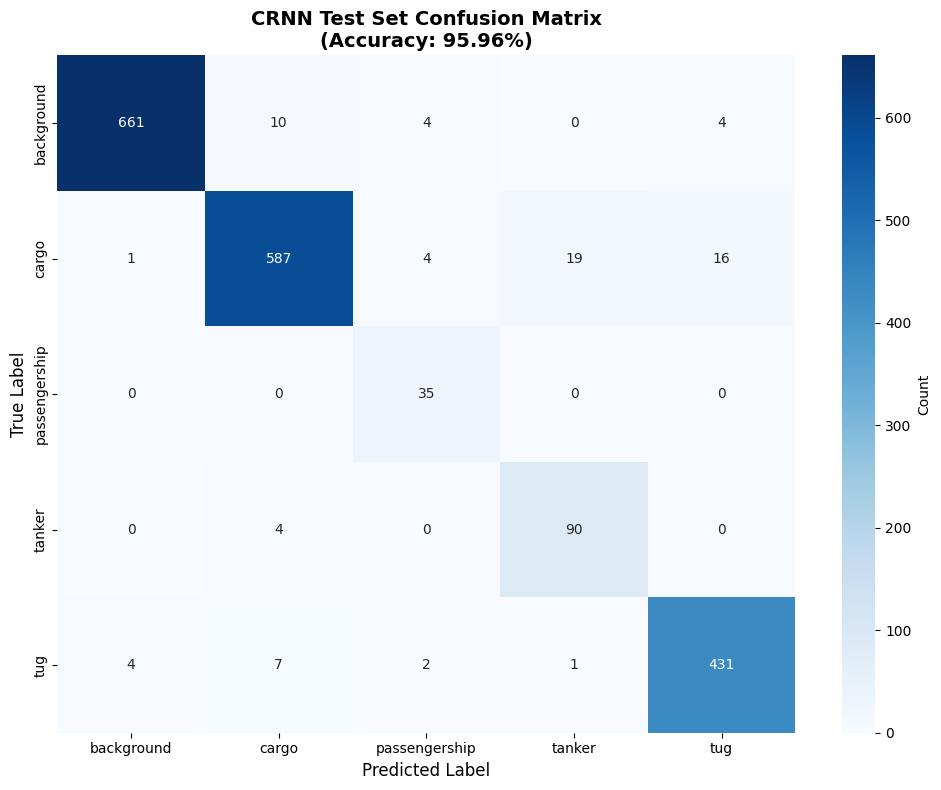

 Saved: crnn_confusion_matrix.png

PREDICTION CONFIDENCE ANALYSIS

Confidence Statistics:
   Mean confidence: 0.9744
   Median confidence: 0.9998
   Min confidence: 0.2531
   Max confidence: 1.0000

Correct predictions confidence: 0.9814 ± 0.0674
Incorrect predictions confidence: 0.8063 ± 0.1778


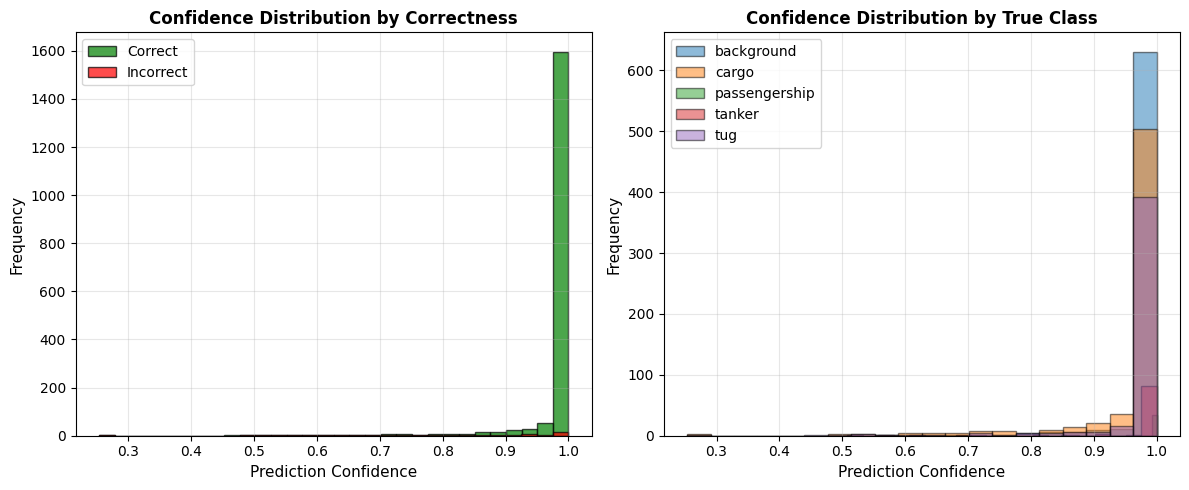

 Saved: crnn_confidence_analysis.png

ERROR ANALYSIS - MISCLASSIFIED SAMPLES

Total misclassified: 76 (4.04%)

Most Common Misclassifications:
   cargo           → tanker         : 19 times
   cargo           → tug            : 16 times
   background      → cargo          : 10 times
   tug             → cargo          : 7 times
   background      → passengership  : 4 times
   background      → tug            : 4 times
   cargo           → passengership  : 4 times
   tanker          → cargo          : 4 times
   tug             → background     : 4 times
   tug             → passengership  : 2 times

 EVALUATION SUMMARY

 CRNN MODEL EVALUATION COMPLETE

Overall Performance:
   - Test Accuracy: 95.96%
   - Test Samples: 1880
   - Misclassified: 76 (4.04%)

Confidence:
   - Correct predictions: 98.14% confidence
   - Incorrect predictions: 80.63% confidence





In [ ]:
print("\n Generating predictions on test set...")

y_true = []
y_pred = []
y_pred_proba = []

for X_batch, y_batch in test_gen:
    if len(y_true) >= len(test_files):
        break

    # Predict
    preds = crnn_model.predict(X_batch, verbose=0)

    # Store
    y_pred_proba.extend(preds)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch, axis=1))

# Trim to exact test size
y_true = np.array(y_true[:len(test_files)])
y_pred = np.array(y_pred[:len(test_files)])
y_pred_proba = np.array(y_pred_proba[:len(test_files)])

print(f" Collected {len(y_pred)} predictions")

# ==============================================================================
# OVERALL METRICS
# ==============================================================================

print("\n" + "="*70)
print("OVERALL TEST PERFORMANCE")
print("="*70)

test_accuracy = (y_pred == y_true).mean()
print(f"\n🎯 Test Accuracy: {test_accuracy*100:.2f}%")

# ==============================================================================
# PER-CLASS METRICS
# ==============================================================================

print("\n" + "="*70)
print("PER-CLASS METRICS")
print("="*70)

class_names = ['background', 'cargo', 'passengership', 'tanker', 'tug']

print("\n" + classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Manual per-class breakdown
print("\nDetailed Per-Class Breakdown:")
for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)
    class_total = class_mask.sum()
    class_correct = ((y_true == i) & (y_pred == i)).sum()
    class_acc = class_correct / class_total if class_total > 0 else 0

    print(f"\n{class_name.upper()}:")
    print(f"   Total samples: {class_total}")
    print(f"   Correct predictions: {class_correct}")
    print(f"   Accuracy: {class_acc*100:.2f}%")

# ==============================================================================
# CONFUSION MATRIX
# ==============================================================================

print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'CRNN Test Set Confusion Matrix\n(Accuracy: {test_accuracy*100:.2f}%)',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ship_models/crnn_confusion_matrix.png', dpi=150)
plt.show()

print(" Saved: crnn_confusion_matrix.png")

# ==============================================================================
# CONFIDENCE ANALYSIS
# ==============================================================================

print("\n" + "="*70)
print("PREDICTION CONFIDENCE ANALYSIS")
print("="*70)

# Get max probability for each prediction
confidences = np.max(y_pred_proba, axis=1)

print(f"\nConfidence Statistics:")
print(f"   Mean confidence: {confidences.mean():.4f}")
print(f"   Median confidence: {np.median(confidences):.4f}")
print(f"   Min confidence: {confidences.min():.4f}")
print(f"   Max confidence: {confidences.max():.4f}")

# Confidence by correctness
correct_mask = (y_pred == y_true)
correct_conf = confidences[correct_mask]
incorrect_conf = confidences[~correct_mask]

print(f"\nCorrect predictions confidence: {correct_conf.mean():.4f} ± {correct_conf.std():.4f}")
print(f"Incorrect predictions confidence: {incorrect_conf.mean():.4f} ± {incorrect_conf.std():.4f}")

# Plot confidence distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(correct_conf, bins=30, alpha=0.7, label='Correct', color='green', edgecolor='black')
plt.hist(incorrect_conf, bins=30, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
plt.xlabel('Prediction Confidence', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Confidence Distribution by Correctness', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
for i, class_name in enumerate(class_names):
    class_conf = confidences[y_true == i]
    plt.hist(class_conf, bins=20, alpha=0.5, label=class_name, edgecolor='black')
plt.xlabel('Prediction Confidence', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Confidence Distribution by True Class', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ship_models/crnn_confidence_analysis.png', dpi=150)
plt.show()

print(" Saved: crnn_confidence_analysis.png")

# ==============================================================================
# ERROR ANALYSIS
# ==============================================================================

print("\n" + "="*70)
print("ERROR ANALYSIS - MISCLASSIFIED SAMPLES")
print("="*70)

# Find misclassified samples
error_indices = np.where(y_pred != y_true)[0]
print(f"\nTotal misclassified: {len(error_indices)} ({len(error_indices)/len(y_true)*100:.2f}%)")

# Most common misclassifications
print("\nMost Common Misclassifications:")
error_pairs = list(zip(y_true[error_indices], y_pred[error_indices]))
from collections import Counter
error_counts = Counter(error_pairs)

for (true_cls, pred_cls), count in error_counts.most_common(10):
    print(f"   {class_names[true_cls]:15s} → {class_names[pred_cls]:15s}: {count} times")

# ==============================================================================
# SUMMARY
# ==============================================================================

print("\n" + "="*70)
print(" EVALUATION SUMMARY")
print("="*70)

print(f"""
 CRNN MODEL EVALUATION COMPLETE

Overall Performance:
   - Test Accuracy: {test_accuracy*100:.2f}%
   - Test Samples: {len(y_true)}
   - Misclassified: {len(error_indices)} ({len(error_indices)/len(y_true)*100:.2f}%)

Confidence:
   - Correct predictions: {correct_conf.mean():.2%} confidence
   - Incorrect predictions: {incorrect_conf.mean():.2%} confidence


""")

print("="*70)